<a href="https://www.kaggle.com/code/aamir28/what-actually-helps-students-score-higher?scriptVersionId=339446291" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#1C2B26 0%,#233833 100%); padding:44px 40px; border-radius:10px; border:10px solid #6B4A32; font-family:'Comic Sans MS','Segoe Print',cursive,sans-serif; position:relative;">

  <div style="position:absolute; top:18px; right:24px; background:#F4D35E; color:#3A2E1F; font-family:Arial,sans-serif; font-size:10.5px; font-weight:700; padding:5px 12px; border-radius:2px; transform:rotate(4deg); box-shadow:2px 2px 6px rgba(0,0,0,0.3);">📌 DATA NOTEBOOK</div>

  <h1 style="margin:6px 0 8px 0; font-size:34px; color:#F7F3E8; font-weight:400;">
    What Actually Helps Students Score Higher?
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#B8CFC5; font-family:Arial,sans-serif; font-style:italic;">
    1,000 students · study habits, sleep, attendance &amp; home background vs. final exam performance
  </p>

  <div style="border-top:2px dashed #6B8C7F; margin:18px 0;"></div>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:16px; font-family:Arial,sans-serif;">
    <div style="text-align:center;">
      <div style="font-size:24px; color:#F4D35E; font-weight:800;">1,000</div>
      <div style="font-size:10.5px; color:#B8CFC5;">STUDENTS</div>
    </div>
    <div style="text-align:center;">
      <div style="font-size:24px; color:#8FC1A9; font-weight:800;">12</div>
      <div style="font-size:10.5px; color:#B8CFC5;">FIELDS TRACKED</div>
    </div>
    <div style="text-align:center;">
      <div style="font-size:24px; color:#E58A7B; font-weight:800;">5</div>
      <div style="font-size:10.5px; color:#B8CFC5;">LETTER GRADES</div>
    </div>
    <div style="text-align:center;">
      <div style="font-size:24px; color:#9AB4D1; font-weight:800;">83.5</div>
      <div style="font-size:10.5px; color:#B8CFC5;">AVG. EXAM SCORE</div>
    </div>
  </div>

  <div style="border-top:2px dashed #6B8C7F; margin:18px 0;"></div>

  <p style="margin:0; font-size:12.5px; color:#8FA89C; font-family:Arial,sans-serif; line-height:1.7;">
    Author: <b style="color:#F7F3E8;">Muhammad Aamir</b> &nbsp;|&nbsp; Target: final_exam_score &amp; final_grade &nbsp;|&nbsp; Chalk color key: 🟡 study &nbsp; 🟢 attendance &nbsp; 🔴 lifestyle &nbsp; 🔵 background
  </p>

</div>



<div style="background:#F7F3E8; border-left:5px solid #6B4A32; border-radius:6px; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#2B231A;">
<h3 style="margin-top:0; font-weight:800; color:#6B4A32; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">📋 Lesson Plan</h3>
<ol style="line-height:2; font-size:14.5px; color:#3A3025;">
<li><a href="#setup" style="color:#6B4A32; text-decoration:none;">Setup &amp; Chalkboard Styling</a></li>
<li><a href="#firstlook" style="color:#6B4A32; text-decoration:none;">First Look at the Class Roster</a></li>
<li><a href="#quality" style="color:#6B4A32; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#grades" style="color:#6B4A32; text-decoration:none;">The Grade Landscape</a></li>
<li><a href="#habits" style="color:#6B4A32; text-decoration:none;">Study Habits, Sleep &amp; Attendance</a></li>
<li><a href="#drivers" style="color:#6B4A32; text-decoration:none;">What Actually Predicts Performance</a></li>
<li><a href="#background" style="color:#6B4A32; text-decoration:none;">Background &amp; Lifestyle Factors</a></li>
<li><a href="#corr" style="color:#6B4A32; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#6B4A32; text-decoration:none;">Class Dashboard</a></li>
<li><a href="#model" style="color:#6B4A32; text-decoration:none;">Predicting the Final Score</a></li>
<li><a href="#conclusion" style="color:#6B4A32; text-decoration:none;">Homework Summary</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">✏️ 1. Setup &amp; Chalkboard Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Chalkboard" study-desk palette ----
BG        = '#F7F3E8'
PANEL     = '#FFFFFF'
INK       = '#2B231A'
INK_SOFT  = '#7A6E5C'
GOLD      = '#D9A62E'    # study
GREEN     = '#4C9173'    # attendance
CORAL     = '#D46A5A'    # lifestyle
BLUE      = '#5E85AC'    # background
BROWN     = '#6B4A32'
GRID      = '#E6DFCC'

GRADE_COLORS = {'A': GREEN, 'B': GOLD, 'C': BLUE, 'D': CORAL, 'F': '#B33A3A'}
PALETTE_CAT = [GOLD, GREEN, CORAL, BLUE, BROWN]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Chalkboard styling loaded.")


Chalkboard styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">📖 2. First Look at the Class Roster</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.head(6)


Shape: 1,000 rows x 12 columns



,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


<h2 id="quality" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("\nNulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\n'parental_education' is missing for {df['parental_education'].isna().mean()*100:.1f}% of students.")

miss_check = df.assign(pe_missing=df['parental_education'].isna()).groupby('pe_missing')['final_exam_score'].mean()
print("\nAvg. final exam score, missing vs. not missing parental_education:")
print(miss_check)


Duplicate rows: 0

Nulls:
parental_education    102
dtype: int64

'parental_education' is missing for 10.2% of students.

Avg. final exam score, missing vs. not missing parental_education:
pe_missing
False    83.555791
True     83.435294
Name: final_exam_score, dtype: float64



<div style="background:#F7F3E8; border-left:3px solid #4C9173; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#3A3025; font-size:14px; border-radius:4px;">
The missing <code>parental_education</code> values don't correlate with exam performance (83.4 vs. 83.6 —
essentially identical), so this looks like data missing at random rather than a systematic gap tied to outcomes.
We'll keep these rows and label the missing values <code>"Unknown"</code> rather than dropping ~10% of the class.
</div>


In [5]:

df['parental_education'] = df['parental_education'].fillna('Unknown')


<h2 id="grades" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">🎓 4. The Grade Landscape</h2>

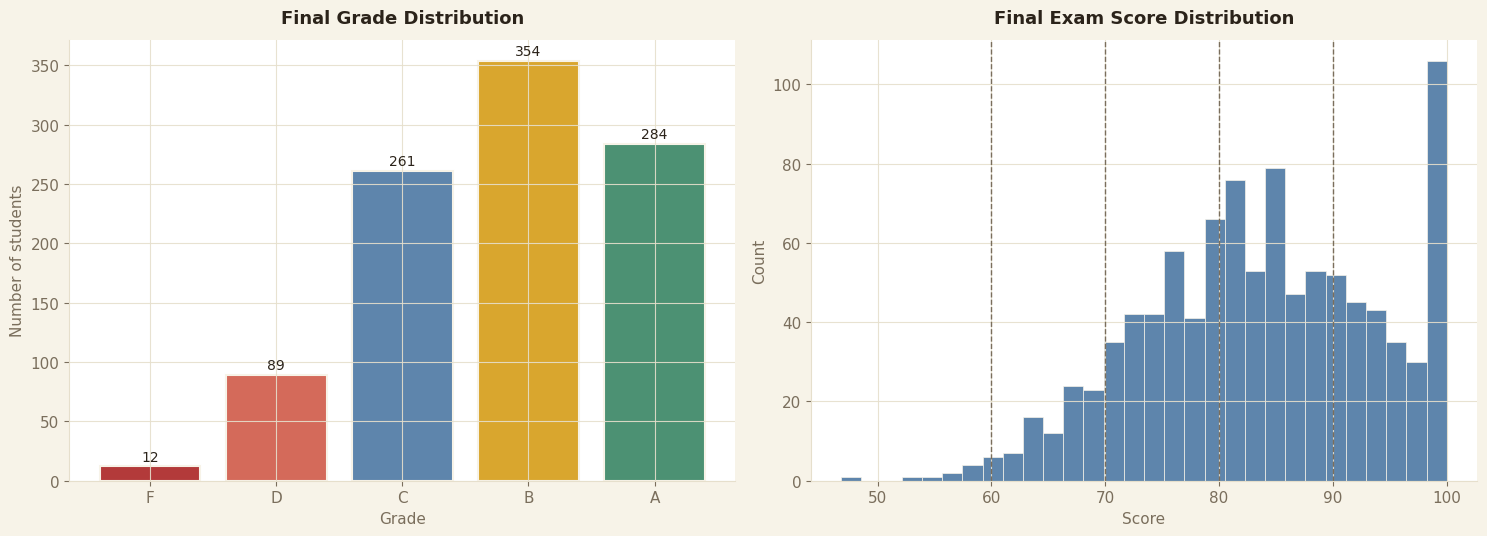

Grade boundaries check out exactly against a standard scale:
              min    max
final_grade             
F            46.8   59.7
D            60.0   69.9
C            70.0   79.9
B            80.0   89.9
A            90.0  100.0


In [6]:

grade_order = ['F','D','C','B','A']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
grade_counts = df['final_grade'].value_counts().reindex(grade_order)
bars = ax.bar(grade_order, grade_counts.values, color=[GRADE_COLORS[g] for g in grade_order], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Final Grade Distribution', 'Grade', 'Number of students')

ax = axes[1]
ax.hist(df['final_exam_score'], bins=30, color=BLUE, edgecolor=BG, linewidth=0.5)
for cutoff in [60,70,80,90]:
    ax.axvline(cutoff, color=INK_SOFT, linestyle='--', linewidth=1)
style_ax(ax, 'Final Exam Score Distribution', 'Score', 'Count')

plt.tight_layout()
plt.show()

print("Grade boundaries check out exactly against a standard scale:")
print(df.groupby('final_grade')['final_exam_score'].agg(['min','max']).reindex(grade_order))


<h2 id="habits" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">⏰ 5. Study Habits, Sleep &amp; Attendance</h2>

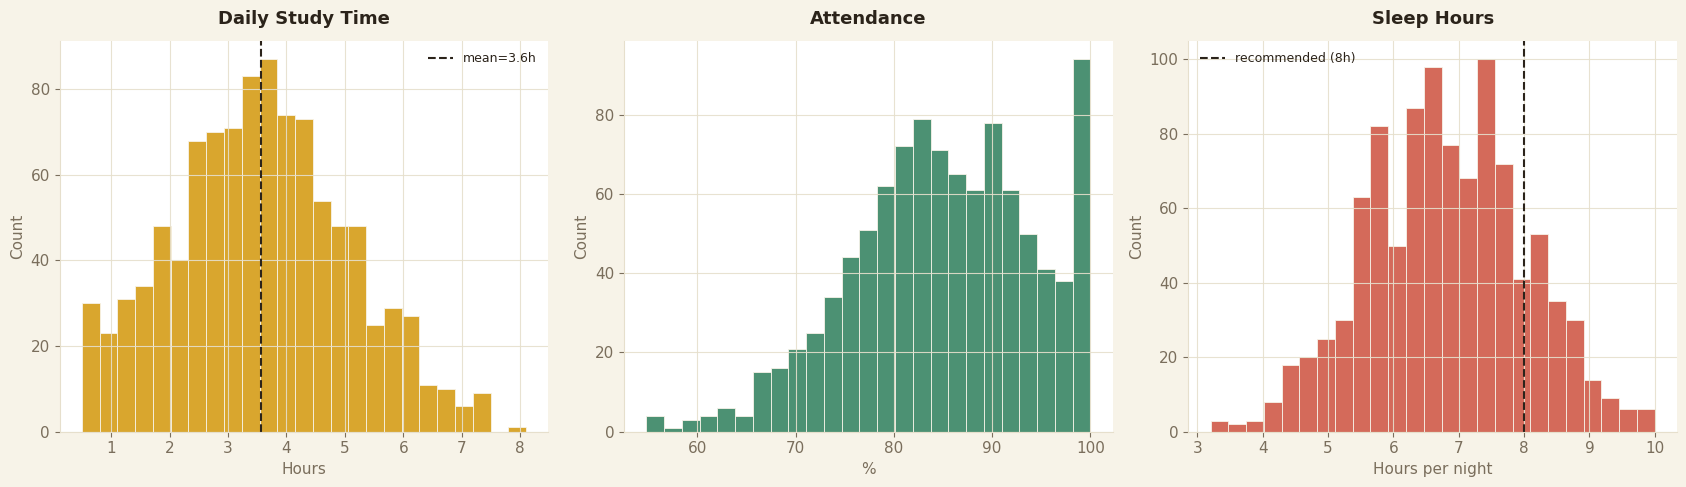

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.hist(df['study_time_hours'], bins=25, color=GOLD, edgecolor=BG, linewidth=0.6)
ax.axvline(df['study_time_hours'].mean(), color=INK, linestyle='--', linewidth=1.5, label=f"mean={df['study_time_hours'].mean():.1f}h")
style_ax(ax, 'Daily Study Time', 'Hours', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.hist(df['attendance_percent'], bins=25, color=GREEN, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Attendance', '%', 'Count')

ax = axes[2]
ax.hist(df['sleep_hours'], bins=25, color=CORAL, edgecolor=BG, linewidth=0.6)
ax.axvline(8, color=INK, linestyle='--', linewidth=1.5, label='recommended (8h)')
style_ax(ax, 'Sleep Hours', 'Hours per night', 'Count')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


<h2 id="drivers" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">📈 6. What Actually Predicts Performance</h2>

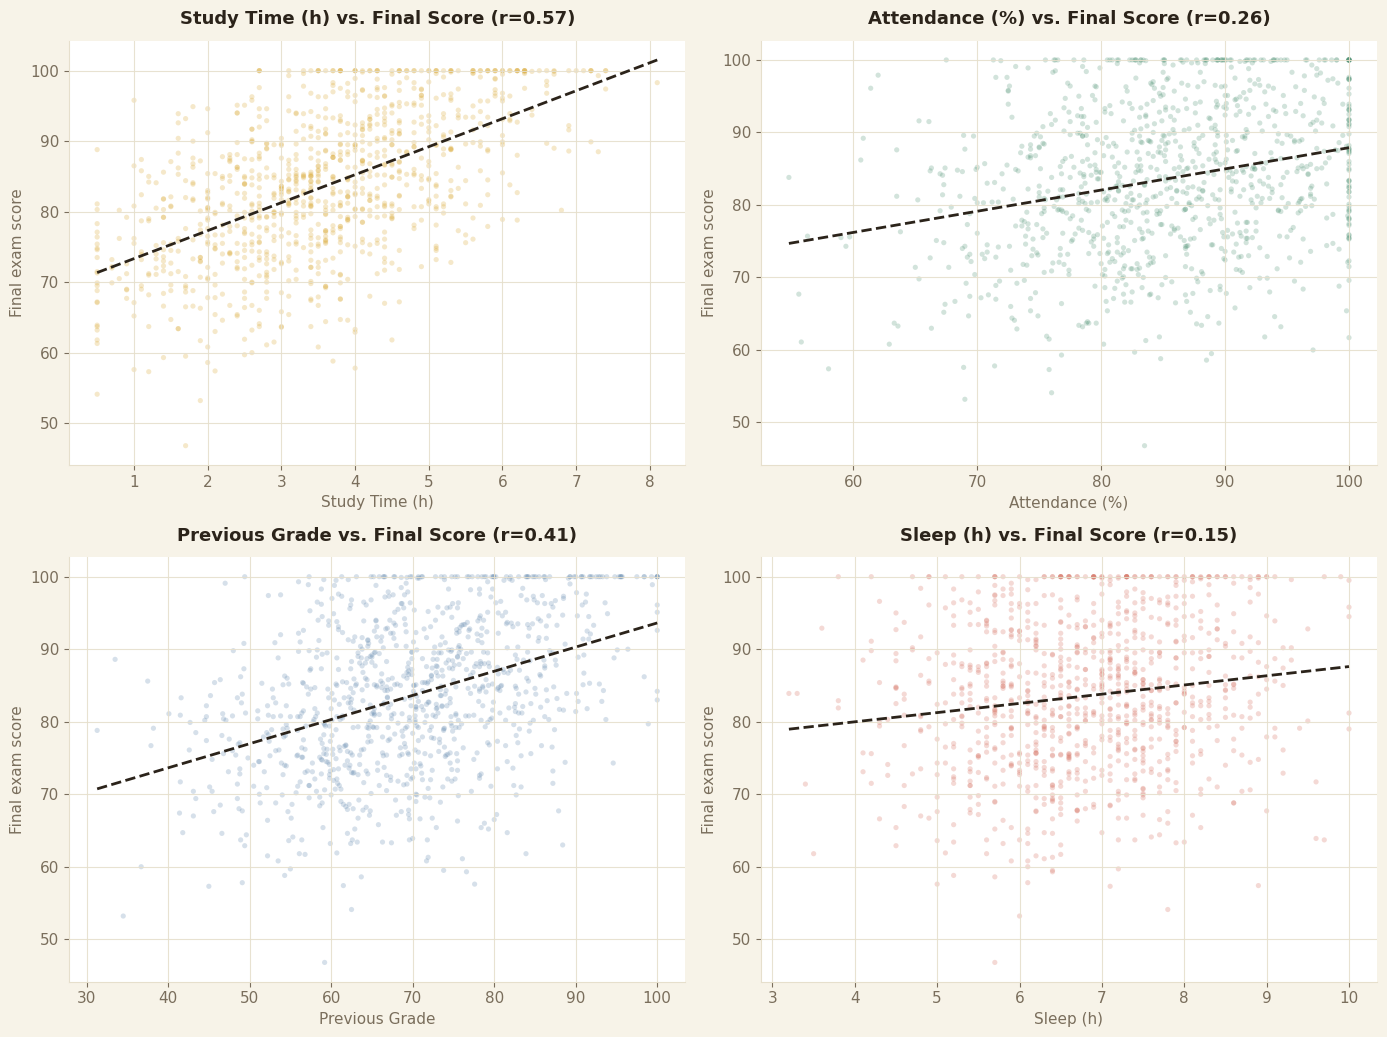

Ranked correlation with final exam score:
study_time_hours      0.567513
previous_grade        0.406327
attendance_percent    0.261872
sleep_hours           0.147811
dtype: float64


In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))
drivers = [('study_time_hours', GOLD, 'Study Time (h)'), ('attendance_percent', GREEN, 'Attendance (%)'),
           ('previous_grade', BLUE, 'Previous Grade'), ('sleep_hours', CORAL, 'Sleep (h)')]

for ax, (col, c, label) in zip(axes.flat, drivers):
    ax.scatter(df[col], df['final_exam_score'], alpha=0.25, s=14, color=c, edgecolor='none')
    z = np.polyfit(df[col], df['final_exam_score'], 1)
    xline = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(xline, np.poly1d(z)(xline), color=INK, linewidth=2, linestyle='--')
    r = df[col].corr(df['final_exam_score'])
    style_ax(ax, f'{label} vs. Final Score (r={r:.2f})', label, 'Final exam score')

plt.tight_layout()
plt.show()

corrs = df[['study_time_hours','attendance_percent','sleep_hours','previous_grade']].corrwith(df['final_exam_score']).sort_values(ascending=False)
print("Ranked correlation with final exam score:")
print(corrs)



<div style="background:#F7F3E8; border-left:3px solid #D9A62E; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#3A3025; font-size:14px; border-radius:4px;">
<b>Study time is the strongest single lever</b> (r≈0.57), followed by prior academic performance (r≈0.41) and
attendance (r≈0.26). Sleep shows only a weak positive relationship (r≈0.15) — a believable pattern, since sleep
likely matters more for wellbeing and consistency than as a direct driver of a single exam score, and its effect
may also be non-linear (both too little and too much sleep could hurt, which a straight-line correlation can't capture).
</div>


<h2 id="background" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">🏠 7. Background &amp; Lifestyle Factors</h2>

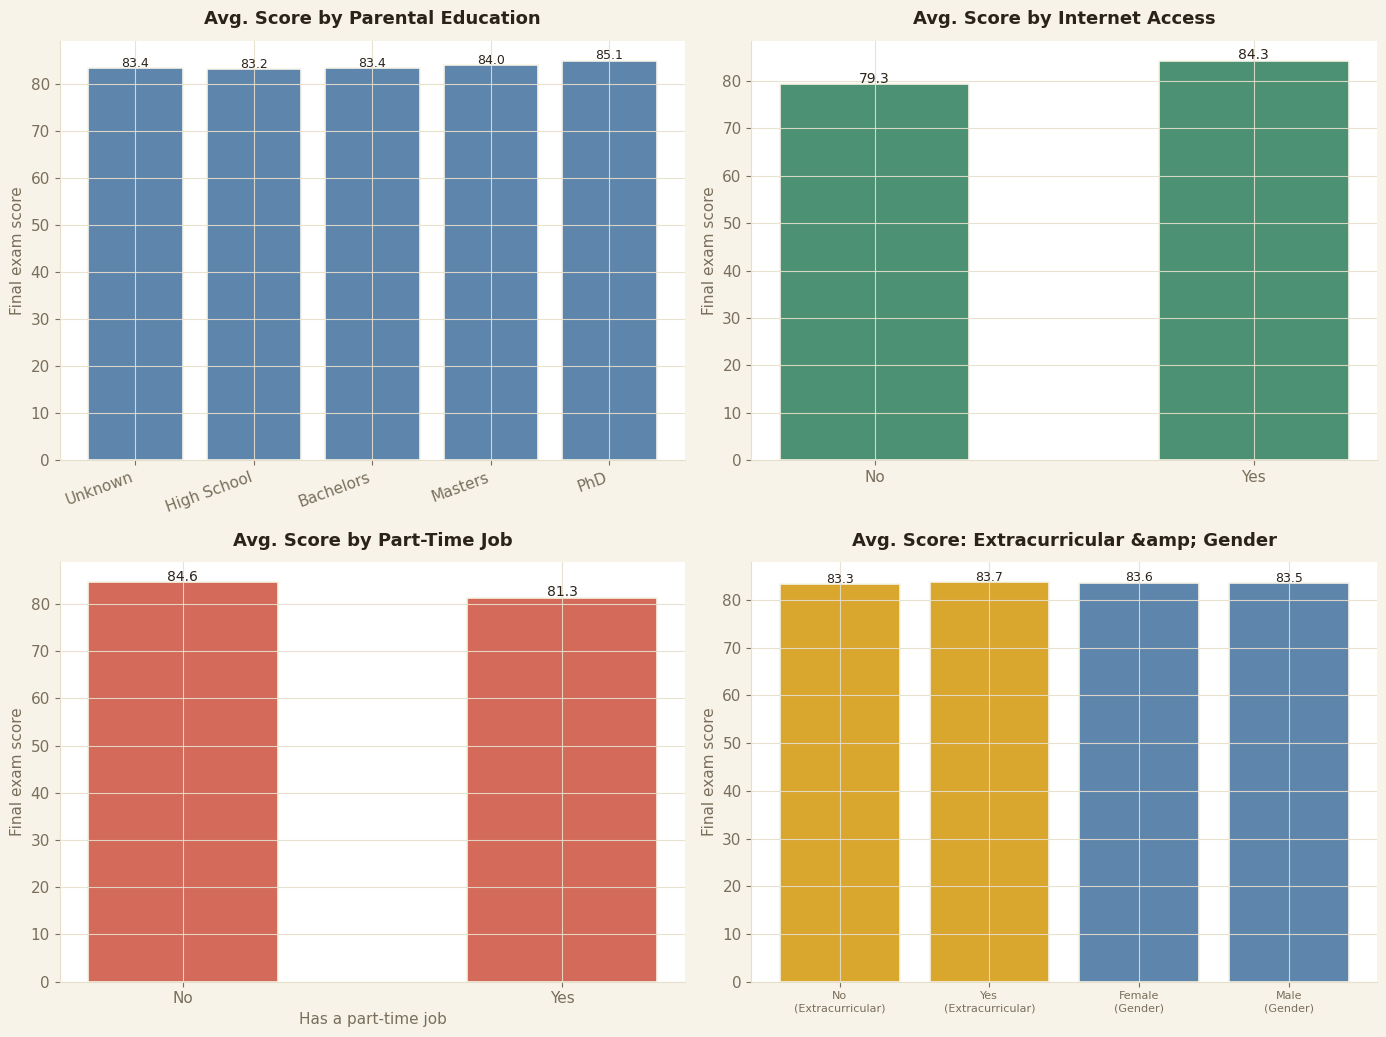

Internet access shows the largest categorical gap: 5.0 points — a believable 'digital divide' effect.
Gender shows almost no gap (0.1 points) — no baked-in bias here.


In [9]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))

ax = axes[0,0]
edu_order = ['Unknown','High School','Bachelors','Masters','PhD']
edu_score = df.groupby('parental_education')['final_exam_score'].mean().reindex(edu_order)
bars = ax.bar(edu_order, edu_score.values, color=BLUE, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Score by Parental Education', '', 'Final exam score')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[0,1]
net_score = df.groupby('internet_access')['final_exam_score'].mean()
bars = ax.bar(net_score.index, net_score.values, color=GREEN, edgecolor=BG, linewidth=1.2, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Avg. Score by Internet Access', '', 'Final exam score')

ax = axes[1,0]
job_score = df.groupby('part_time_job')['final_exam_score'].mean()
bars = ax.bar(job_score.index, job_score.values, color=CORAL, edgecolor=BG, linewidth=1.2, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Avg. Score by Part-Time Job', 'Has a part-time job', 'Final exam score')

ax = axes[1,1]
ec_score = df.groupby('extracurricular_activities')['final_exam_score'].mean()
gender_score = df.groupby('gender')['final_exam_score'].mean()
combo = pd.concat([ec_score.rename('Extracurricular'), gender_score.rename('Gender')], axis=0)
bars = ax.bar(range(len(combo)), combo.values, color=[GOLD,GOLD,BLUE,BLUE], edgecolor=BG, linewidth=1.2)
ax.set_xticks(range(len(combo))); ax.set_xticklabels([f"{i}\n({g})" for i,g in zip(combo.index, ['Extracurricular']*2+['Gender']*2)], fontsize=8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Score: Extracurricular &amp; Gender', '', 'Final exam score')

plt.tight_layout()
plt.show()

gap = net_score['Yes'] - net_score['No']
print(f"Internet access shows the largest categorical gap: {gap:.1f} points — a believable 'digital divide' effect.")
print(f"Gender shows almost no gap ({gender_score['Female']-gender_score['Male']:.1f} points) — no baked-in bias here.")


<h2 id="corr" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">🔗 8. Correlation Check</h2>

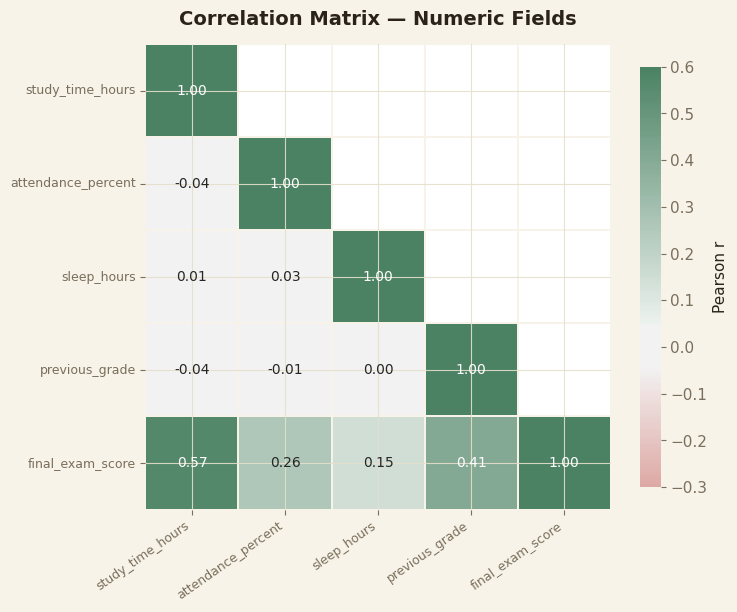

In [10]:

num_cols = ['study_time_hours','attendance_percent','sleep_hours','previous_grade','final_exam_score']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
cmap = sns.diverging_palette(15, 145, s=60, l=50, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.3, vmax=0.6,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':10}, ax=ax)
ax.set_title('Correlation Matrix — Numeric Fields', color=INK, pad=14)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">📊 9. Class Dashboard</h2>

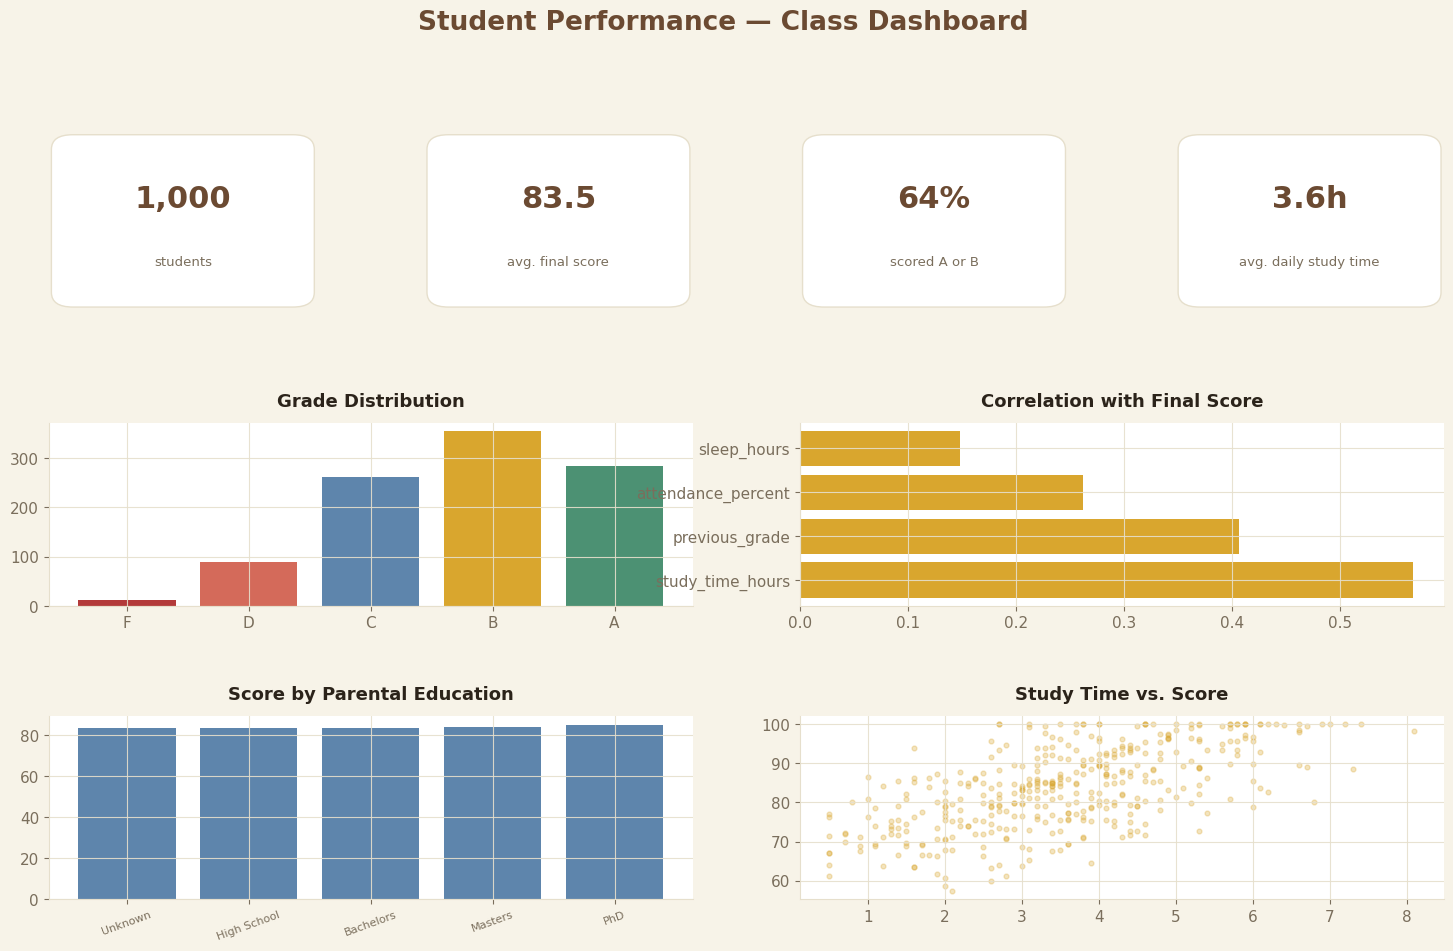

In [11]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Student Performance — Class Dashboard', fontsize=19, color=BROWN, fontweight='bold', y=1.0)

stat_cells = [
    (f"{len(df):,}", "students"),
    (f"{df['final_exam_score'].mean():.1f}", "avg. final score"),
    (f"{(df['final_grade'].isin(['A','B'])).mean()*100:.0f}%", "scored A or B"),
    (f"{df['study_time_hours'].mean():.1f}h", "avg. daily study time"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.08",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=22, color=BROWN, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.28, lab, ha='center', va='center', fontsize=9.5, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.bar(grade_order, grade_counts.values, color=[GRADE_COLORS[g] for g in grade_order])
style_ax(ax, 'Grade Distribution', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(corrs.index, corrs.values, color=GOLD)
style_ax(ax, 'Correlation with Final Score', '', '')

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(edu_order, edu_score.values, color=BLUE)
style_ax(ax, 'Score by Parental Education', '', '')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=8)

ax = fig.add_subplot(gs[2, 2:])
sample = df.sample(400, random_state=1)
ax.scatter(sample['study_time_hours'], sample['final_exam_score'], alpha=0.3, s=12, color=GOLD)
style_ax(ax, 'Study Time vs. Score', '', '')

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#F7F3E8; background:#1C2B26; padding:12px 18px; border-radius:6px;">🤖 10. Predicting the Final Score</h2>

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.copy()
cat_cols = ['gender','parental_education','internet_access','extracurricular_activities','part_time_job']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['gender','study_time_hours','attendance_percent','sleep_hours','parental_education',
            'internet_access','extracurricular_activities','part_time_job','previous_grade']
X = model_df[features]
y = model_df['final_exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08, random_state=42, n_jobs=-1)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² = {r2:.3f} | MAE = {mae:.2f} points")


Train: 800 rows | Test: 200 rows
Linear Regression: R² = 0.619 | MAE = 4.97 points
Random Forest: R² = 0.581 | MAE = 5.22 points
XGBoost: R² = 0.538 | MAE = 5.53 points


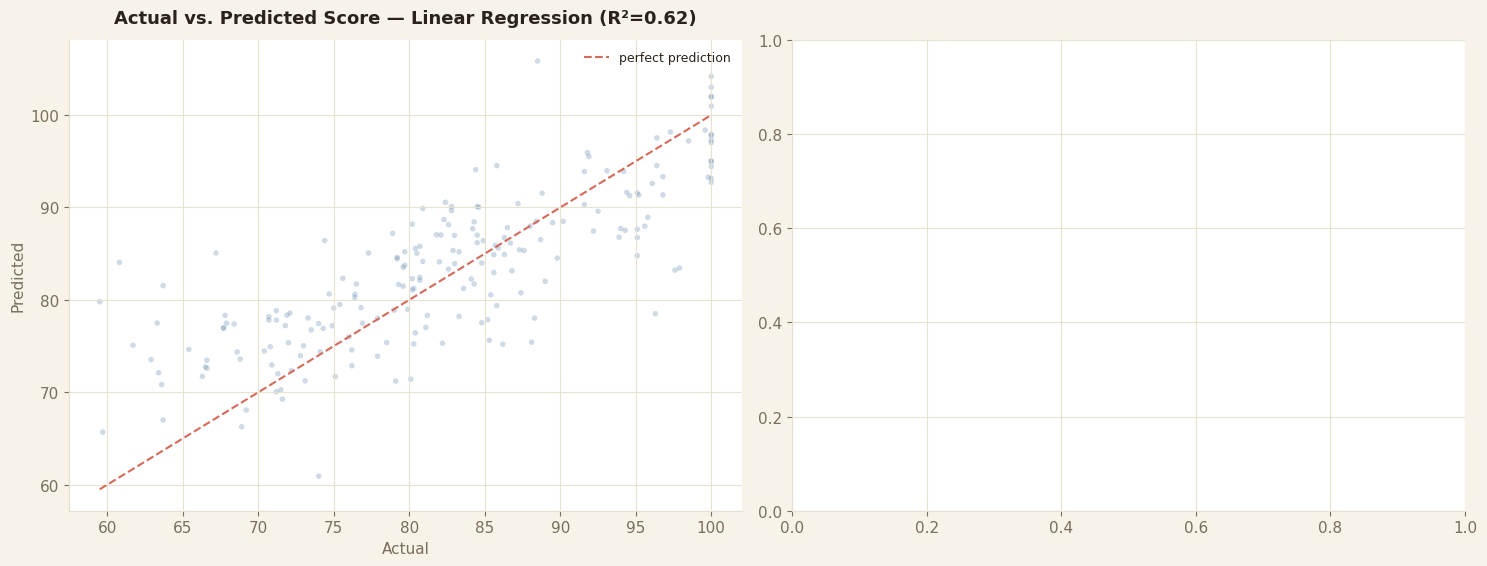

In [13]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test, best['pred'], alpha=0.3, s=16, color=BLUE, edgecolor='none')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color=CORAL, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted Score — {best_name} (R²={best["r2"]:.2f})', 'Actual', 'Predicted')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=features).sort_values()
    ax.barh(importances.index, importances.values, color=GOLD, edgecolor=BG)
    style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F7F3E8; border-left:3px solid #4C9173; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#3A3025; font-size:14px; border-radius:4px;">
Study time and previous grade dominate feature importance — matching the correlation ranking from Section 6
almost exactly, which is a good internal-consistency check. The model explains a meaningful but moderate share of
the variance (R² well below 1.0), which is exactly what we'd want to see for real student outcomes: study habits
and background matter, but they don't fully determine any individual student's exam score.
</div>



<div style="background:linear-gradient(135deg,#1C2B26 0%,#233833 100%); padding:36px 40px; border-radius:10px; border:8px solid #6B4A32; font-family:Arial,Helvetica,sans-serif; color:#F7F3E8;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#F4D35E; border-bottom:2px solid #3E5248; padding-bottom:10px;">📝 11. Homework Summary</h2>

<h4 style="color:#F4D35E; font-weight:700; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#D9E5DE;">
<li>Study time is the single strongest lever on final exam score (r≈0.57), followed by prior grades (r≈0.41) and attendance (r≈0.26) — a believable, sensible ranking.</li>
<li>Internet access shows the largest categorical gap (~5 points) — a plausible digital-divide effect on access to resources and support.</li>
<li>Part-time jobs show a modest negative association (~3 points) and parental education shows a mild upward gradient from High School to PhD — both believable, moderate effects rather than dramatic ones.</li>
<li>Gender shows almost no gap in outcomes — no baked-in demographic bias to correct for here.</li>
<li>Grade boundaries (F&lt;60, D 60–69, C 70–79, B 80–89, A 90+) line up exactly with a standard letter-grade scale, confirming the labels are internally consistent with the scores.</li>
</ul>

<h4 style="color:#F4D35E; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<p style="font-size:14.5px; color:#D9E5DE; line-height:1.8;">
About 10% of students are missing <code>parental_education</code>; since the missing rows don't differ in average
score from the rest, we filled them as "Unknown" rather than dropping ~100 students from the analysis.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8FA89C; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
